In [1]:
import numpy as np

In [2]:
W_true=[3, -2, 5]
b_true = 4

In [3]:
rng=np.random.default_rng(seed=42)

In [4]:
X=rng.random(size=(13,3))

In [5]:
y = np.dot(X,np.array(W_true)) + b_true +rng.normal(loc=0.0,scale=0.001,size=(13,))

In [6]:
print(y.shape)

(13,)


In [7]:
print(y)

[ 9.73775146 10.7826044   5.35240181  9.2427212   6.50337529  3.89174956
  9.01022211  7.58865889  8.27970169  7.23875599  5.92846137  5.11991341
  4.5735327 ]


In [8]:
def compute_cost(X, y, w,b):
    m = X.shape[0]
    predictions = X @ w + b
    J=(1/(2*m))*np.sum(np.power((predictions-y),2))
    return J

In [9]:
def compute_gradient(X,y,w,b):
    m=X.shape[0]
    predictions=X @ w + b
    djw=(1/m)* X.T @ (predictions-y)
    djb=(1/m)*np.sum((predictions-y))
    return djw,djb

In [10]:
def gradient_descent(X,y,w,b,alpha,maximum_iterations):
    i=0
    previous_cost=0
    current_costs=[]
    while True:
        dw,db=compute_gradient(X,y,w,b)
        w=w-alpha*dw
        b=b-alpha*db
        i+=1
        if i%20 == 0 :
            print(f"Iteration {i}: cost = {compute_cost(X, y, w, b)}")
        current_cost=compute_cost(X,y,w,b)
        current_costs.append(current_cost)
        if abs(previous_cost - current_cost) < 1e-8:
            print("The cost is saturated")
            break
        previous_cost=current_cost
        if i>=maximum_iterations:
            print("the minimum_iterations have exceeded")
            break
        if np.linalg.norm(dw) < 1e-6 and abs(db) < 1e-6:
                    print("the gardients are approaching 0")
                    break
    return w,b,current_costs

In [11]:
wi=np.zeros(3)
bi=0
w_final, b_final,currentcostss = gradient_descent(X, y, wi, bi, alpha=0.1, maximum_iterations=2000)
print("Learned w:", w_final)
print("Learned b:", b_final)
print("True w:", W_true, "True b:", b_true)

Iteration 20: cost = 0.8954910950415256
Iteration 40: cost = 0.5674125484980461
Iteration 60: cost = 0.3643988917076731
Iteration 80: cost = 0.23596277114452865
Iteration 100: cost = 0.1544010288545671
Iteration 120: cost = 0.10234964146078086
Iteration 140: cost = 0.06891698767732139
Iteration 160: cost = 0.04726500103628858
Iteration 180: cost = 0.03309527949582086
Iteration 200: cost = 0.02370142304699516
Iteration 220: cost = 0.017375684325178508
Iteration 240: cost = 0.013037349787391517
Iteration 260: cost = 0.009999898971997361
Iteration 280: cost = 0.007825038170916428
Iteration 300: cost = 0.006231129692706961
Iteration 320: cost = 0.005035690948547387
Iteration 340: cost = 0.004119241438016508
Iteration 360: cost = 0.0034025335270752768
Iteration 380: cost = 0.0028321801726528236
Iteration 400: cost = 0.002371556006370309
Iteration 420: cost = 0.0019950144372582663
Iteration 440: cost = 0.0016841935463541042
Iteration 460: cost = 0.001425640737536944
Iteration 480: cost = 0.0

In [12]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X, y)
w_sklearn = model.coef_
b_sklearn = model.intercept_

In [13]:
print("Weightsfronsklearn:", w_sklearn)
print("Biasfromsklearn:", b_sklearn)


Weightsfronsklearn: [ 2.99977353 -1.99994078  5.00014481]
Biasfromsklearn: 4.000363564840086


In [14]:
print("Difference in w:", np.abs(w_sklearn - w_final))
print("Difference in b:", abs(b_sklearn - b_final))

Difference in w: [0.00213119 0.0053226  0.00406978]
Difference in b: 0.00404877997069919


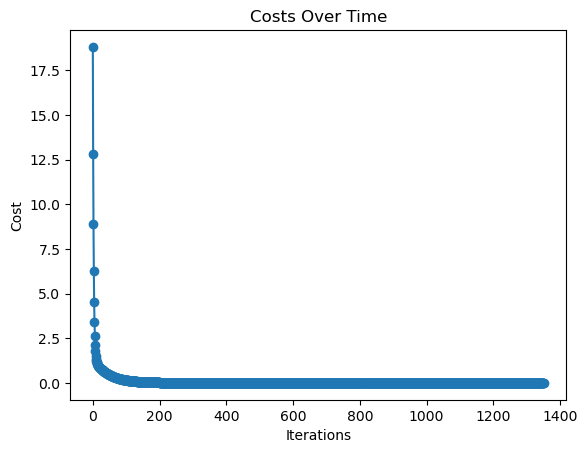

In [ ]:
import matplotlib.pyplot as plt

# Pass the entire list at once instead of looping
plt.plot(currentcostss, marker='o') 
'''Because plt.plot() expects a sequence of points to connect, passing a single x and y coordinate inside a for loop 
creates isolated individual points with a line length of zero. As a result, your plot will appear completely blank'''
#want a single point use scatter using for loop

plt.title("Costs Over Time")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()




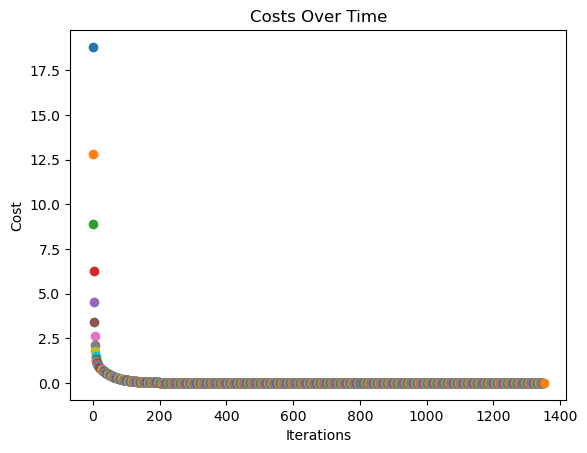

In [24]:
for i in range(len(currentcostss)):
    plt.scatter(i,currentcostss[i])
plt.title("Costs Over Time")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()